# background_stats

> Calculate statistics to determine the surface brightness and spatial scale of the background variations.

In [ ]:
# | default_exp euclid.background_stats

In [ ]:
# | export

from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from astropy.io import fits
from astropy import table
from astropy.convolution import convolve, TrapezoidDisk2DKernel
from matplotlib.ticker import FuncFormatter, NullLocator
from matplotlib import patheffects as pe
from scipy.stats import bootstrap, median_abs_deviation

from photutils.aperture import (
    CircularAperture,
    CircularAnnulus,
    RectangularAperture,
    RectangularAnnulus,
    ApertureStats,
)
from photutils.background import Background2D
from tqdm import tqdm

from nicl.mask import fast_mask, plot_mask

In [ ]:
# | hide

from FyeldGenerator import generate_field
from scipy.stats import norm

from nicl.euclid.utilities import default_data_path


In [ ]:
# | export


def measure_aperture_stats(
    data,
    mask,
    n_apertures,
    sqrt_n_pix,
    aperture_shape,
    annular_thickness=None,
):
    if aperture_shape == "square":
        outer_size = sqrt_n_pix
    if aperture_shape == "circle":
        outer_size = sqrt_n_pix * 2 / np.sqrt(np.pi)

    annulus = annular_thickness is not None and annular_thickness < 1
    if sqrt_n_pix < 3:
        # does not make sense to use an annulus for small numbers of pixels
        annulus = False
    
    if annulus:
        outer_size = outer_size / np.sqrt(1 - (1 - annular_thickness) ** 2)
        inner_size = (1 - annular_thickness) * outer_size
    else:
        inner_size = 0

    x = np.random.uniform(outer_size / 2, data.shape[1] - outer_size / 2, n_apertures)
    y = np.random.uniform(outer_size / 2, data.shape[0] - outer_size / 2, n_apertures)
    positions = np.transpose(np.vstack((x, y)))

    if aperture_shape == "square":
        if annulus:
            ap = RectangularAnnulus(
                positions,
                w_in=inner_size,
                w_out=outer_size,
                h_in=inner_size,
                h_out=outer_size,
            )
        else:
            ap = RectangularAperture(positions, w=outer_size, h=outer_size)
    elif aperture_shape == "circle":
        if annulus:
            ap = CircularAnnulus(positions, r_in=inner_size / 2, r_out=outer_size / 2)
        else:
            ap = CircularAperture(positions, r=outer_size / 2)

    stats = ApertureStats(data, ap, mask=mask, sum_method="center", )
    stats = stats.to_table(columns=("sum_aper_area", "mean", "median"))
    return stats, outer_size


def aperture_stats(
    data,
    mask,
    n_apertures,
    sqrt_n_pix,
    aperture_shape,
    annular_thickness=None,
    n_pix_tolerance=0.1,
    verbose=False,
):
    n_pix = sqrt_n_pix**2
    if verbose:
        print(f"n_apertures: {n_apertures}")
        print(f"target n_pix: {n_pix}")
        print(f"sqrt_n_pix: {sqrt_n_pix}")
    sqrt_n_pix_adjusted = sqrt_n_pix
    i = 0
    previous_stats = None
    while True:
        i += 1
        stats, outer_size = measure_aperture_stats(data, mask, n_apertures, sqrt_n_pix_adjusted, aperture_shape, annular_thickness)
        achieved_n_pix = stats["sum_aper_area"].value
        ok = abs(achieved_n_pix - n_pix) / n_pix < n_pix_tolerance
        n_ok = ok.sum()
        n_nan = np.isnan(achieved_n_pix).sum()
        if verbose:
            print(f"n_ok: {n_ok}")
            print(f"n_nan: {n_nan}")
            print(f"median achieved_n_pix: {np.nanmedian(achieved_n_pix):.0f}")
        sqrt_n_pix_adjustment = np.sqrt(n_pix / np.nanmedian(achieved_n_pix))
        stats = stats[ok]
        if previous_stats is not None:
            stats = table.vstack([previous_stats, stats], metadata_conflicts="silent")
        previous_stats = stats
        n_ok = len(stats)
        if n_ok / n_apertures > 0.9 or i > 2:
            break
        else:
            sqrt_n_pix_adjusted *= sqrt_n_pix_adjustment
            if verbose:
                print(f"trying again after adjusting sqrt_n_pix to {sqrt_n_pix_adjusted:.0f}")
    if verbose:
        print(f"total number of valid apertures: {n_ok}")
    std = partial(median_abs_deviation, axis=None, scale="normal")
    std_mean = float(std(stats["mean"]))
    err_std_mean = float(std_mean / np.sqrt(2 * n_ok - 2))
    err_std_mean_bootstrap = float(bootstrap((stats["mean"],), std, n_resamples=1000).standard_error)
    std_median = float(std(stats["median"]))
    err_std_median = float(std_median / np.sqrt(2 * n_ok - 2))
    err_std_median_bootstrap = float(bootstrap((stats["median"],), std, n_resamples=1000).standard_error)
    results = dict(
        sqrt_n_pix=sqrt_n_pix,
        std_mean=std_mean,
        err_std_mean=err_std_mean,
        err_bs_std_mean=err_std_mean_bootstrap,
        std_median=std_median,
        err_std_median=err_std_median,
        err_bs_std_median=err_std_median_bootstrap,
        n_ok=n_ok,
        outer_size=float(outer_size),
    )
    return results

In [ ]:
# | export


def stats_versus_size(
    data,
    mask,
    n_apertures,
    max_sqrt_n_pix,
    aperture_shape,
    annular_thickness=None,
    n_pix_tolerance=0.1,
    n_steps=20,
    rms=None,
    verbose=False,
):
    sqrt_n_pix_list = np.logspace(0, np.log10(max_sqrt_n_pix), n_steps)
    sqrt_n_pix_list = np.unique(sqrt_n_pix_list.astype(int))
    results = []
    for sqrt_n_pix in tqdm(sqrt_n_pix_list):
        results.append(
            aperture_stats(
                data,
                mask,
                n_apertures=n_apertures,
                sqrt_n_pix=sqrt_n_pix,
                aperture_shape=aperture_shape,
                annular_thickness=annular_thickness,
                n_pix_tolerance=n_pix_tolerance,
                verbose=verbose,
            )
        )
    results = table.Table(results)
    results["expected_std_mean"] = results["std_mean"][0] / results["sqrt_n_pix"]
    results["expected_std_median"] = (
        np.sqrt(np.pi / 2) * results["std_median"][0] / results["sqrt_n_pix"]
    )
    if rms is not None:
        expected_rms = np.median(rms[~mask])
        results["expected_std_from_rms_mean"] = expected_rms / results["sqrt_n_pix"]
        results["expected_std_from_rms_median"] = (
            np.sqrt(np.pi / 2) * expected_rms / results["sqrt_n_pix"]
        )
    return results

In [ ]:
# | export

def convert_to_mag(results, zp):
    results["expected_std_mean"] = zp - 2.5 * np.log10(results["expected_std_mean"])
    results["expected_std_median"] = zp - 2.5 * np.log10(results["expected_std_median"])
    results["err_std_mean"] = (results["err_std_mean"] / results["std_mean"]) * 2.5 / np.log(10)
    results["err_std_median"] = (results["err_std_median"] / results["std_median"]) * 2.5 / np.log(10)
    results["err_bs_std_mean"] = (results["err_bs_std_mean"] / results["std_mean"]) * 2.5 / np.log(10)
    results["err_bs_std_median"] = (results["err_bs_std_median"] / results["std_median"]) * 2.5 / np.log(10)
    results["std_mean"] = zp - 2.5 * np.log10(results["std_mean"])
    results["std_median"] = zp - 2.5 * np.log10(results["std_median"])
    if "expected_std_from_rms_mean" in results.columns:
        results["expected_std_from_rms_mean"] = zp - 2.5 * np.log10(results["expected_std_from_rms_mean"])
    if "expected_std_from_rms_median" in results.columns:
        results["expected_std_from_rms_median"] = zp - 2.5 * np.log10(results["expected_std_from_rms_median"])
    return results

In [ ]:
# | export


def background_stats_plot(results, true_bkg_std=None, errorbars=False, zp_mag=None, filename=None):
    if zp_mag is not None:
        results = convert_to_mag(results, zp_mag)
    fig, ax = plt.subplots()
    ax.plot(
        results["sqrt_n_pix"],
        results["expected_std_mean"],
        "--",
        color="purple",
        label="expected std(mean)",
    )
    if errorbars:
        ax.errorbar(
            results["sqrt_n_pix"],
            results["std_mean"],
            results["err_bs_std_mean"],
            fmt="-s",
            color="purple",
            label="measured std(mean)",
        )
    else:
        ax.plot(
            results["sqrt_n_pix"], results["std_mean"], "-s", color="purple", label="measured std(mean)"
        )
    ax.plot(
        results["sqrt_n_pix"],
        results["expected_std_median"],
        "--",
        color="green",
        label="expected std(median)",
    )
    if errorbars:
        ax.errorbar(
            results["sqrt_n_pix"],
            results["std_median"],
            results["err_bs_std_median"],
            fmt="-o",
            color="green",
            label="measured std(median)",
        )
    else:
        ax.plot(
            results["sqrt_n_pix"],
            results["std_median"],
            "-o",
            color="green",
            label="measured std(median)",
        )
    if "expected_std_from_rms_mean" in results.columns:
        ax.plot(1, results["expected_std_from_rms_mean"][0], "*", color="red", mfc="none", markersize=20, label="expected rms", zorder=10)
    if true_bkg_std is not None:
        ax.axhline(true_bkg_std, ls=":", label="true bkg std")
    ax.set_xscale("log")
    if zp_mag is None:
        ax.set_yscale("log")
    else:
        ax.set_ylim(30, 24.5)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
    ax.xaxis.set_ticks(results["sqrt_n_pix"])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("sqrt(n_pix)")
    ax.set_ylabel("std(average)")
    ax.tick_params(axis='x', labelrotation=90)
    ax.legend()
    if filename is not None:
        fig.savefig(filename)

In [ ]:
# | export


def measure(
    filename,  # the filename to test
    path,  # the folder containing the images
    mask=None,  # an optional mask to apply to the image
    create_mask=True,  # generate and apply a mask if not supplied
    estimate_background=True,  # allow masking to estimate the background from the median of the image
    bkg_mesh_size=None,  # size of the background mesh boxes in pixels
    bkg_filter_size=None,  # median filter background over `bkg_filter_size` x `bkg_filter_size` boxes
    plots=True,  # output plots
    outpath=None,  # the folder where all output plots should be placed
    separate_detectors=True,  # consider multiple science extensions individually
    n_apertures=1000,  # number of apertures per size
    max_sqrt_n_pix=500,  # maximum aperture size as sqrt(number of pixels)
    aperture_shape="square",  # square or circle
    annular_thickness=None,  # None for solid apertures, or a number on range (0, 1) to specify relative thickness of annulus
    n_pix_tolerance=0.1,  # the largest allowed relative deviation from the requested n_pix
    n_steps=25,  # the number of different sqrt_n_pix to measure
    zp_mag=21.286,  # convert to magntiudes using this zero point, unless it is None
    errorbars=True,  # plot errorbars
    debug=False,  # save debug images
    verbose=False,  # print verbose output
):
    """Determine statistics of the background."""
    path = Path(path).expanduser()
    if outpath is not None:
        outpath = Path(outpath).expanduser()
    else:
        outpath = path / "background_stats"
    results = {}
    fn = path / filename
    with fits.open(fn, memmap=True) as hdul:
        sci_ext = [hdu.name for hdu in hdul if "SCI" in hdu.name]
        multi_ext = len(sci_ext) > 1
        for ext in sci_ext:
            if multi_ext:   
                out_fn_stem = f"{fn.stem}_{ext}"
            else:
                out_fn_stem = f"{fn.stem}"
            data = hdul[ext].data
            rms = hdul[ext.replace("SCI", "RMS")].data
            data_mask = (rms > 1e6) | np.isnan(rms) | np.isnan(data)
            data[data_mask] = np.nan
            rms[data_mask] = np.nan
            if mask is None:
                if create_mask:
                    mask, _ = fast_mask(data, estimate_background=estimate_background, verbose=verbose)
                else:
                    mask = np.zeros(data.shape, dtype=bool)
            mask |= data_mask
            if bkg_mesh_size is not None:
                bkg_filter_size = 3 if bkg_filter_size is None else bkg_filter_size
                bg = Background2D(
                    data,
                    bkg_mesh_size,
                    mask=mask,
                    filter_size=bkg_filter_size,
                    exclude_percentile=90.0,
                )
                data = data - bg.background
            ext_results = stats_versus_size(
                data,
                mask,
                n_apertures=n_apertures,
                max_sqrt_n_pix=max_sqrt_n_pix,
                aperture_shape=aperture_shape,
                annular_thickness=annular_thickness,
                n_pix_tolerance=n_pix_tolerance,
                n_steps=n_steps,
                rms=rms,
                verbose=verbose,
            )
            outfile = (outpath / f"{out_fn_stem}.fits")
            outfile.parent.mkdir(parents=True, exist_ok=True)
            ext_results.write(outfile, overwrite=True)
            if plots:
                outfile = (outpath / f"{out_fn_stem}.pdf")
                background_stats_plot(ext_results, zp_mag=zp_mag, filename=outfile, errorbars=errorbars)
            if debug:
                fits.writeto(outpath / f"{out_fn_stem}_mask.fits", mask.astype(np.int8), overwrite=True)
                fits.writeto(outpath / f"{out_fn_stem}_data.fits", data, overwrite=True)
                masked_data = data.copy()
                masked_data[mask] = np.nan
                fits.writeto(outpath / f"{out_fn_stem}_masked_data.fits", masked_data, overwrite=True)
            results[ext] = ext_results
    if not separate_detectors:
        results = table.vstack(results.values())
    elif len(results) == 1:
        results = list(results.values())[0]
    return results, mask

## Test

Test the performance on images containing random noise and a background varying on a particular spatial scale.

In [ ]:
def _distrib(shape):
    a = np.random.normal(loc=0, scale=1, size=shape)
    b = np.random.normal(loc=0, scale=1, size=shape)
    return a + 1j * b


def create_test_background(
    shape=(2040, 1020),  # shape of the simulated image,
    rms=1.0,  # rms of the Gaussian background noise, in absence of spatial variations
    background_scale=100,  # scale, in pixels, of the spatial background variations
    background_rms=0.1,  # rms of the spatial background variations
):  # `random`, `background`, `random_with_background`
    """Create a background image for testing.

    A `random` flat background is created by sampling a Gaussian distribution with the
    specified `rms`. A spatially varying `background` is created as a Gaussian random field,
    with a Gaussian power spectrum, centred at zero wavelength with a standard deviation of
    0.1 / `background_scale`. This produces smooth spatial features on scales on the order of
    `background_scale`. This spatially varying background is scaled to have an rms of`
    `background_rms`. The two are summed to produce `random_with_background`.
    """
    random = norm(0, rms).rvs(size=shape)
    background = generate_field(_distrib, norm(0, 0.1 / background_scale).pdf, shape)
    background *= background_rms / background.std()
    random_with_background = random + background
    return random, background, random_with_background


def create_test_mask(
    shape=(2040, 1020),  # shape of the simulated image,
    scale=100,  # scale, in pixels, of the spatial variations used to create the mask
    threshold=1.5,  # threshold of the spatial variations, as a multiple of the rms
):  # boolean `mask`, in which True means a pixel should be masked
    """Create an arbitrary mask for testing, by thresholding a Guassian random field."""
    mask = generate_field(_distrib, norm(0, 1 / scale).pdf, shape)
    mask = mask > threshold * mask.std()
    return mask

In [ ]:
def correlate_pixels(img, slope=0.8):
    kernel = TrapezoidDisk2DKernel(0, slope)
    n = kernel.shape[0]
    f_centre = kernel.array[(n - 1)//2, (n - 1)//2]
    print(f"Fraction of flux in central pixel is {100*f_centre:.0f}%")
    convolved_img = convolve(img, kernel)
    return convolved_img

In [ ]:
random, background, random_with_background = create_test_background()

In [ ]:
random_convolved = correlate_pixels(random, slope=0.8)
random_with_background_convolved = random_convolved + background

Fraction of flux in central pixel is 56%


In [ ]:
mask = create_test_mask()
no_mask = mask * False

In [ ]:
def plot_test_images(random, background, random_with_background, mask, circles=True):
    fig, ax = plt.subplots(1, 4, figsize=(12, 6))
    for a in ax:
        a.set_xticks([])
        a.set_yticks([])
    vmin, vmax = np.percentile(random, (0.1, 99.9))
    ax[0].imshow(random, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[1].imshow(background, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[2].imshow(random_with_background, vmin=vmin, vmax=vmax, cmap="seismic", interpolation="none")
    ax[3].imshow(mask, cmap="seismic", interpolation="none")
    if circles:
        x = 120
        for i, radius in enumerate((10, 20, 40, 80)):
            circle = plt.Circle((x + radius, 150), radius, ec="w", fc="none", lw=5)
            ax[1].add_patch(circle)
            circle = plt.Circle((x + radius, 150), radius, ec="k", fc="none")
            ax[1].add_patch(circle)
            rlabel = "r=" if i == 0 else ""
            ax[1].annotate(f"{rlabel}{radius}px", (x + radius, 220 + radius), ha="center", color="k",
                           path_effects=[pe.withStroke(linewidth=4, foreground="white")])
            x += 2 * radius + 160
    plt.tight_layout()

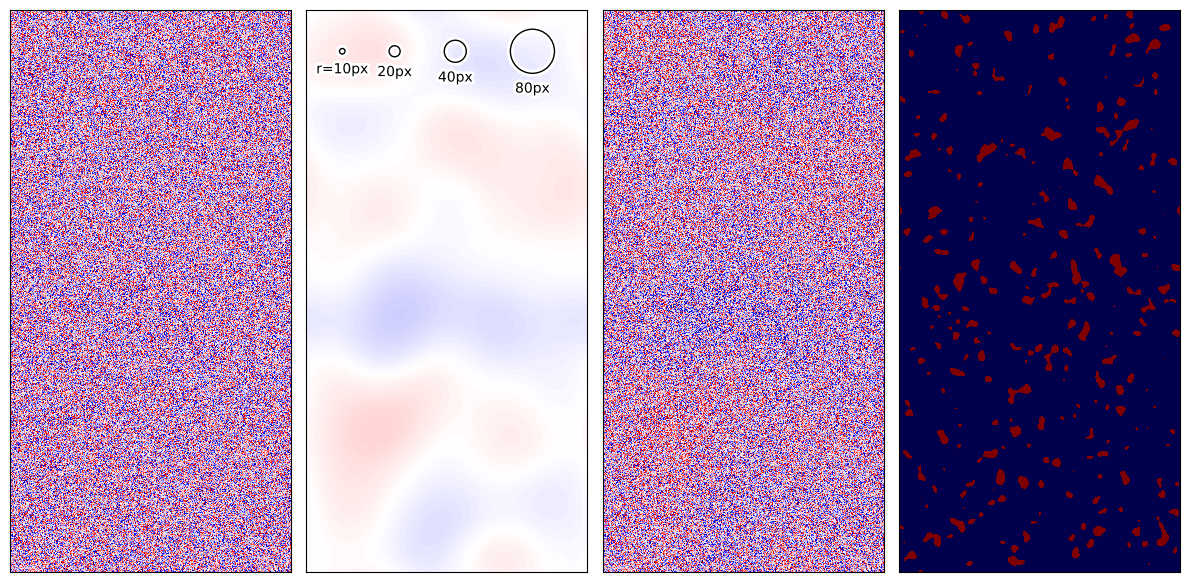

In [ ]:
plot_test_images(random, background, random_with_background, mask, circles=True)

Calculate the standard deviation of the average over many apertures of a given size.

First with no mask and square apertures.

In [ ]:
results = aperture_stats(
    random,
    no_mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="square",
    annular_thickness=None,
    n_pix_tolerance=0.1,
)
assert results["n_ok"] == 100
results

{'sqrt_n_pix': 100,
 'std_mean': 0.011652701035549523,
 'err_std_mean': 0.0008281214027523073,
 'err_bs_std_mean': 0.0014788890071086211,
 'std_median': 0.014385695184775869,
 'err_std_median': 0.0010223468395558902,
 'err_bs_std_median': 0.001720138926068358,
 'n_ok': 100,
 'outer_size': 100.0}

Now with a mask, note that `n_ok` decrease a bit, but the `outer_size` has increased to compensate for the masking.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=100, aperture_shape="square")

{'sqrt_n_pix': 100,
 'std_mean': 0.010640632552699984,
 'err_std_mean': 0.0006063063098004395,
 'err_bs_std_mean': 0.001255093870725557,
 'std_median': 0.015468685711158633,
 'err_std_median': 0.0008814101703583011,
 'err_bs_std_median': 0.0014221043475477323,
 'n_ok': 155,
 'outer_size': 104.24587657074937}

Let's compare the processed and convolved images for a single pixel.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=1, aperture_shape="square")

{'sqrt_n_pix': 1,
 'std_mean': 1.1026342873655994,
 'err_std_mean': 0.08218550736238392,
 'err_bs_std_mean': 0.12319267303034391,
 'std_median': 1.1026342873655994,
 'err_std_median': 0.08218550736238392,
 'err_bs_std_median': 0.12957831019126048,
 'n_ok': 91,
 'outer_size': 1.0}

In [ ]:
aperture_stats(random_convolved, mask, n_apertures=100, sqrt_n_pix=1, aperture_shape="square")

{'sqrt_n_pix': 1,
 'std_mean': 0.6374144368297997,
 'err_std_mean': 0.0462429035397268,
 'err_bs_std_mean': 0.054899006274273104,
 'std_median': 0.6374144368297997,
 'err_std_median': 0.0462429035397268,
 'err_bs_std_median': 0.058848572522037894,
 'n_ok': 96,
 'outer_size': 1.0}

Try a square annulus. The `outer_size` has increased to achieve the same number of pixels.

In [ ]:
aperture_stats(
    random,
    mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="square",
    annular_thickness=0.5,
)

{'sqrt_n_pix': 100,
 'std_mean': 0.010071180353321068,
 'err_std_mean': 0.0005461864412050487,
 'err_bs_std_mean': 0.0008873593494736441,
 'std_median': 0.012765125340734516,
 'err_std_median': 0.000692286121069517,
 'err_bs_std_median': 0.0011256707375732504,
 'n_ok': 171,
 'outer_size': 119.46420987063144}

Try a circle. The `outer_size` has increased to achieve the same number of pixels as a square.

In [ ]:
aperture_stats(random, mask, n_apertures=100, sqrt_n_pix=100, aperture_shape="circle")

{'sqrt_n_pix': 100,
 'std_mean': 0.011087054179622255,
 'err_std_mean': 0.0006103222456878436,
 'err_bs_std_mean': 0.0008884833970862474,
 'std_median': 0.013835633385534073,
 'err_std_median': 0.0007616265512522785,
 'err_bs_std_median': 0.001216313237294726,
 'n_ok': 166,
 'outer_size': 115.98311008499694}

Try a circular annulus. Again, the `outer_size` has increased to achieve the same number of pixels.

In [ ]:
aperture_stats(
    random,
    mask,
    n_apertures=100,
    sqrt_n_pix=100,
    aperture_shape="circle",
    annular_thickness=0.5,
)

{'sqrt_n_pix': 100,
 'std_mean': 0.010746697172463538,
 'err_std_mean': 0.0005880331066198105,
 'err_bs_std_mean': 0.0008173153908989058,
 'std_median': 0.01240048099267681,
 'err_std_median': 0.000678524131152389,
 'err_bs_std_median': 0.001165817547631959,
 'n_ok': 168,
 'outer_size': 133.94345013558936}

Now try with a spatially varying background. On small scales, the standard deviations match the processed pixel rms, but on larger scales they match the strength of the background variations.

In [ ]:
aperture_stats(
    random_with_background, mask, n_apertures=100, sqrt_n_pix=1, aperture_shape="square"
)

{'sqrt_n_pix': 1,
 'std_mean': 1.3609407441738581,
 'err_std_mean': 0.10032988276594754,
 'err_bs_std_mean': 0.16732059412579073,
 'std_median': 1.3609407441738581,
 'err_std_median': 0.10032988276594754,
 'err_bs_std_median': 0.16578965693440814,
 'n_ok': 93,
 'outer_size': 1.0}

In [ ]:
aperture_stats(
    random_with_background,
    mask,
    n_apertures=1000,
    sqrt_n_pix=100,
    aperture_shape="square",
)

{'sqrt_n_pix': 100,
 'std_mean': 0.11121740730152073,
 'err_std_mean': 0.001961777866606403,
 'err_bs_std_mean': 0.0026279748298198556,
 'std_median': 0.10977298838340036,
 'err_std_median': 0.0019362995792372873,
 'err_bs_std_median': 0.0026499362551201675,
 'n_ok': 1608,
 'outer_size': 103.06266543483376}

Now let's measure the statistics in apertures of a series of sizes. First with no spatially varying background.

In [ ]:
results_no_bkg = stats_versus_size(
    random, mask, n_apertures=100, max_sqrt_n_pix=250, aperture_shape="square"
)

100%|██████████| 18/18 [00:01<00:00, 10.18it/s]


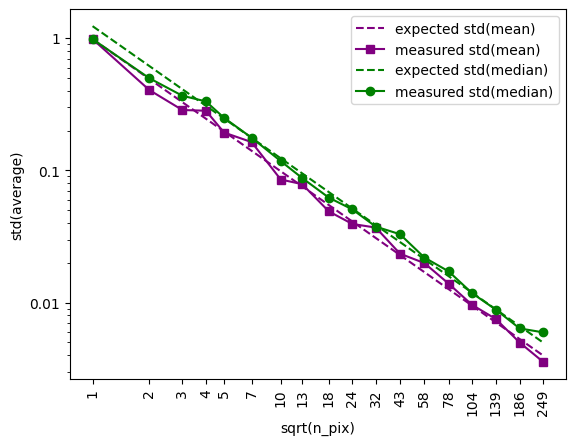

In [ ]:
background_stats_plot(results_no_bkg)

What about if the pixels are a bit correlated (i.e. by a convolution)?

In [ ]:
results_no_bkg_convolved = stats_versus_size(
    random_convolved, mask, n_apertures=100, max_sqrt_n_pix=250, aperture_shape="square"
)

100%|██████████| 18/18 [00:02<00:00,  7.53it/s]


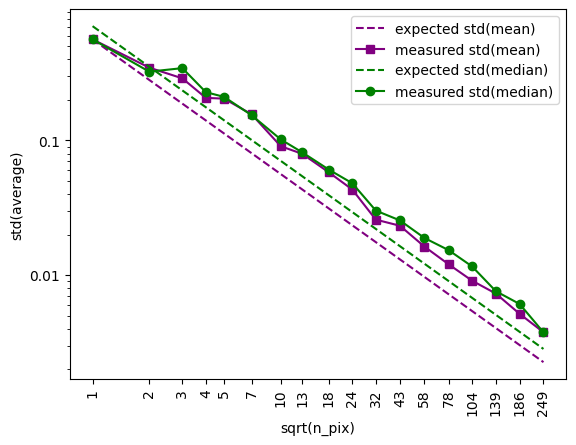

In [ ]:
background_stats_plot(results_no_bkg_convolved)

And now with a spatially varying background.

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:02<00:00,  8.13it/s]


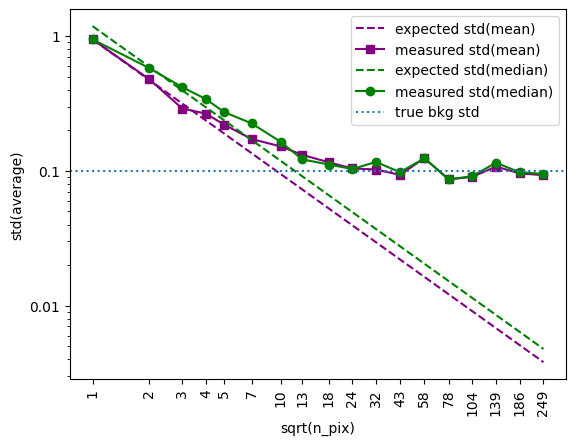

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.1)

And again, what about if the pixels are a bit correlated (i.e. by a convolution)?

In [ ]:
results_with_bkg_convolved = stats_versus_size(
    random_with_background_convolved,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:01<00:00,  9.65it/s]


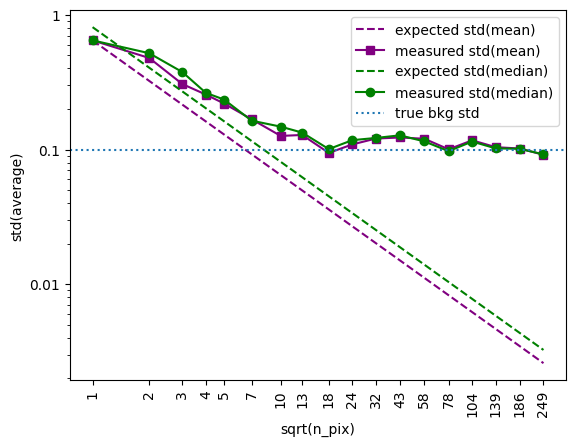

In [ ]:
background_stats_plot(results_with_bkg_convolved, true_bkg_std=0.1)

Create a background containing spatial variations with a different rms, to compare.

In [ ]:
random, background, random_with_background = create_test_background(background_rms=0.2)

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:02<00:00,  8.20it/s]


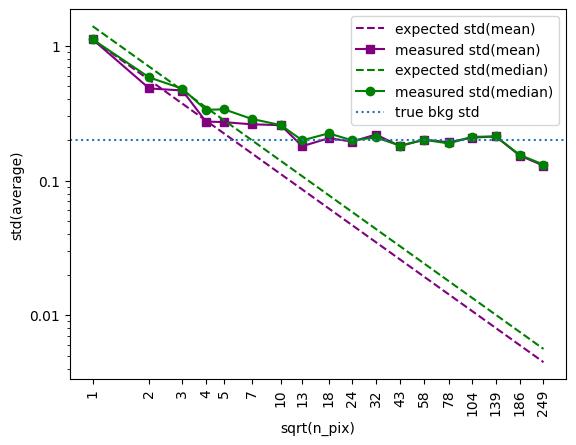

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.2)

Create a background containing spatial variations on a different scale, to compare.

In [ ]:
random, background, random_with_background = create_test_background(
    background_scale=10
)

In [ ]:
random_convolved = correlate_pixels(random, slope=0.8)
random_with_background_convolved = random_convolved + background

Fraction of flux in central pixel is 56%


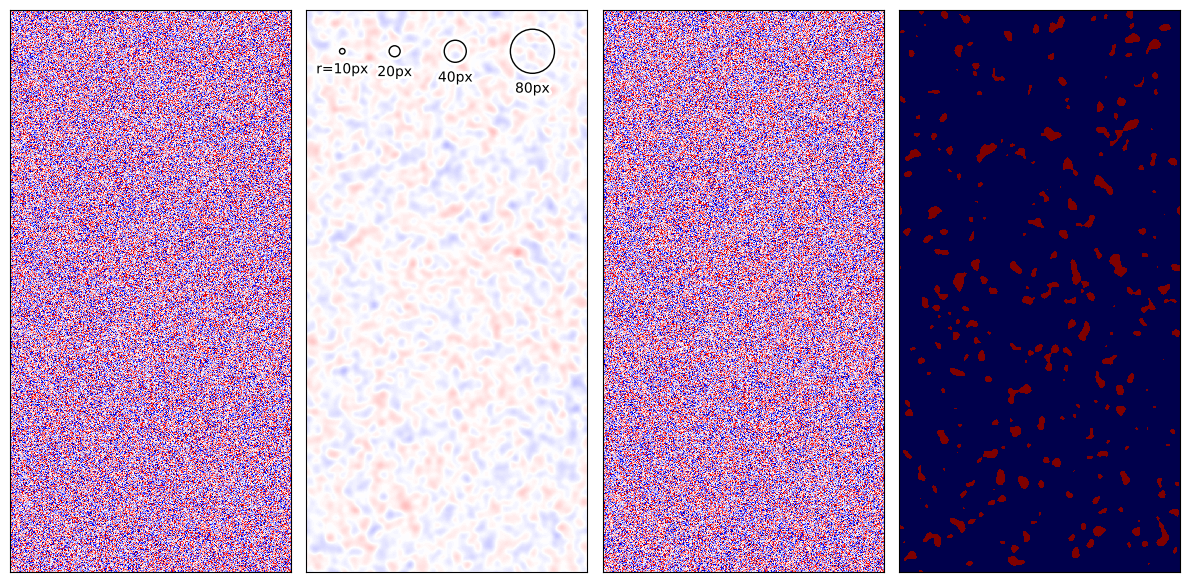

In [ ]:
plot_test_images(random, background, random_with_background, mask)

In [ ]:
results_with_bkg = stats_versus_size(
    random_with_background,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:01<00:00,  9.39it/s]


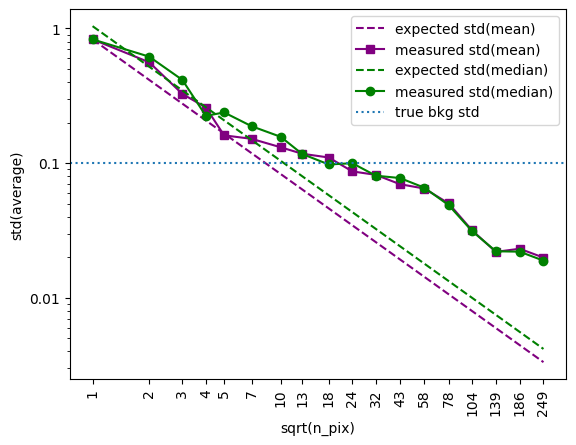

In [ ]:
background_stats_plot(results_with_bkg, true_bkg_std=0.1)

In [ ]:
results_with_bkg_convolved = stats_versus_size(
    random_with_background_convolved,
    mask,
    n_apertures=100,
    max_sqrt_n_pix=250,
    aperture_shape="square",
)

100%|██████████| 18/18 [00:02<00:00,  8.90it/s]


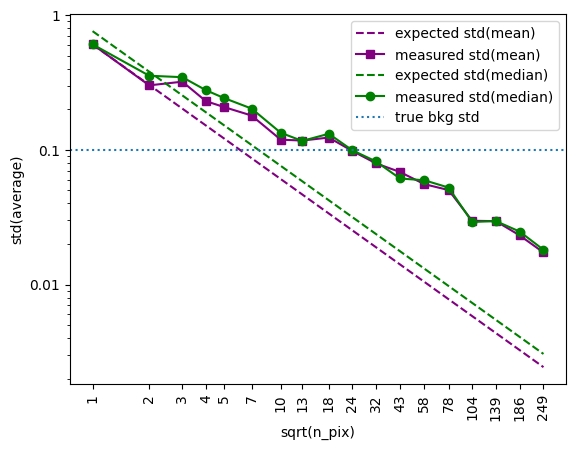

In [ ]:
background_stats_plot(results_with_bkg_convolved, true_bkg_std=0.1)

## Example

The following is an example of using `measure` on an observation.

Fast mask
    smoothing image with sigma of 1.0 pixels
    iteration 0
    estimating background
    eroding mask with 1 iterations
    dilating mask with radius 2.0 pixels for 2 iterations
    background RMS is 0.026
    iteration 1
    estimating background
    eroding mask with 1 iterations
    dilating mask with radius 2.0 pixels for 2 iterations
    background RMS is 0.024
    iteration 2
    estimating background
    eroding mask with 1 iterations
    dilating mask with radius 2.0 pixels for 2 iterations
    background RMS is 0.024


  0%|          | 0/22 [00:00<?, ?it/s]

n_apertures: 1000
target n_pix: 1
sqrt_n_pix: 1
n_ok: 435
n_nan: 565
median achieved_n_pix: 1.0
trying again after adjusting sqrt_n_pix to 1.0
n_ok: 425
n_nan: 575
median achieved_n_pix: 1.0
trying again after adjusting sqrt_n_pix to 1.0
n_ok: 428
n_nan: 572
median achieved_n_pix: 1.0
total number of valid apertures: 1288


  5%|▍         | 1/22 [00:00<00:07,  2.64it/s]

n_apertures: 1000
target n_pix: 4
sqrt_n_pix: 2
n_ok: 423
n_nan: 550
median achieved_n_pix: 4.0
trying again after adjusting sqrt_n_pix to 2.0
n_ok: 424
n_nan: 552
median achieved_n_pix: 4.0
trying again after adjusting sqrt_n_pix to 2.0
n_ok: 421
n_nan: 554
median achieved_n_pix: 4.0
total number of valid apertures: 1268


...

n_ok: 474
n_nan: 414
median achieved_n_pix: 88079.0
total number of valid apertures: 1082
n_apertures: 1000
target n_pix: 148225
sqrt_n_pix: 385
n_ok: 141
n_nan: 427
median achieved_n_pix: 129370.0
trying again after adjusting sqrt_n_pix to 412.1019503811199
n_ok: 443
n_nan: 412
median achieved_n_pix: 147812.0
trying again after adjusting sqrt_n_pix to 412.67727371113193


 95%|█████████▌| 21/22 [01:01<00:11, 11.89s/it]

n_ok: 436
n_nan: 400
median achieved_n_pix: 147804.0
total number of valid apertures: 1020
n_apertures: 1000
target n_pix: 249001
sqrt_n_pix: 499
n_ok: 117
n_nan: 402
median achieved_n_pix: 216750.0
trying again after adjusting sqrt_n_pix to 534.8371158484074
n_ok: 474
n_nan: 367
median achieved_n_pix: 246928.0
trying again after adjusting sqrt_n_pix to 537.0774452015621


100%|██████████| 22/22 [01:45<00:00,  4.80s/it]

n_ok: 431
n_nan: 389
median achieved_n_pix: 248871.0
total number of valid apertures: 1022


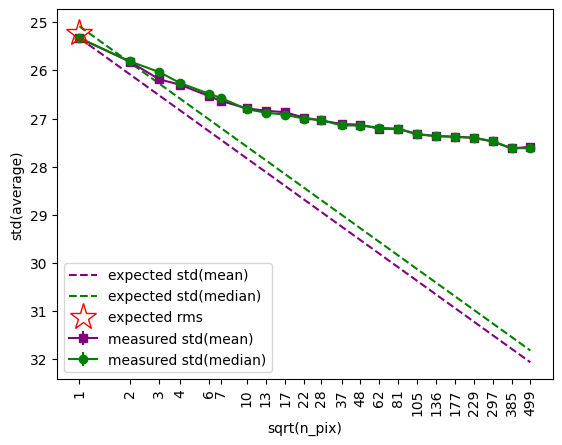

In [ ]:
path = default_data_path("Q1_R1_processed_v0.4")
filename = "NIR/2683/EUC_NIR_W-STK_Y_2683.fits"
results_original, mask_original = measure(filename, path / "stacked_original", debug=True, verbose=True)

100%|██████████| 22/22 [01:30<00:00,  4.11s/it]


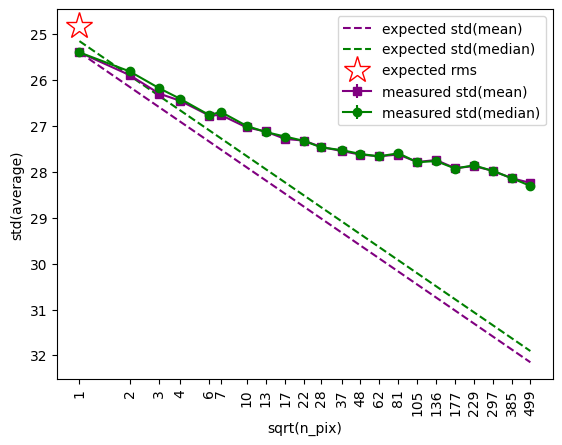

In [ ]:
path = default_data_path("Q1_R1_processed_v0.4")
filename = "NIR/2683/EUC_NIR_W-STK_Y_2683.fits"
results_processed, mask_processed = measure(filename, path / "stacked")

In [ ]:
mask = mask_original | mask_processed

100%|██████████| 22/22 [01:32<00:00,  4.22s/it]


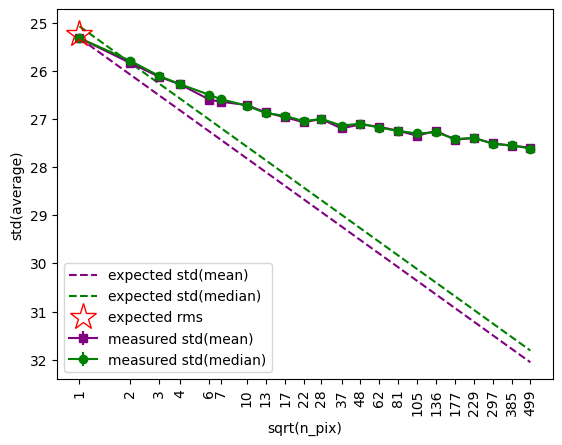

In [ ]:
results_original_remasked, _ = measure(filename, path / "stacked_original", mask=mask, outpath=path / "stacked_original" / "background_stats_remasked")

100%|██████████| 22/22 [01:34<00:00,  4.30s/it]


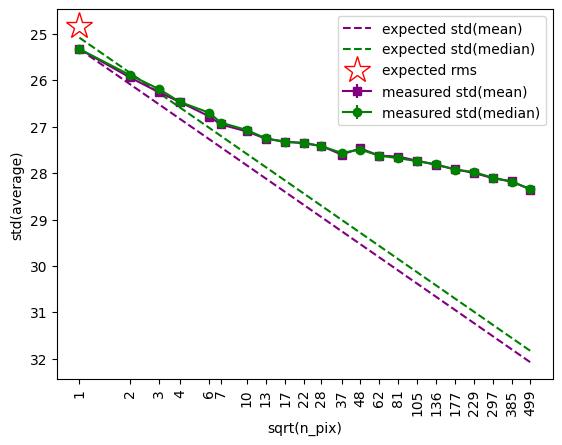

In [ ]:
results_processed, _ = measure(filename, path / "stacked", mask=mask, outpath=path / "stacked" / "background_stats_remasked")

100%|██████████| 22/22 [01:30<00:00,  4.12s/it]


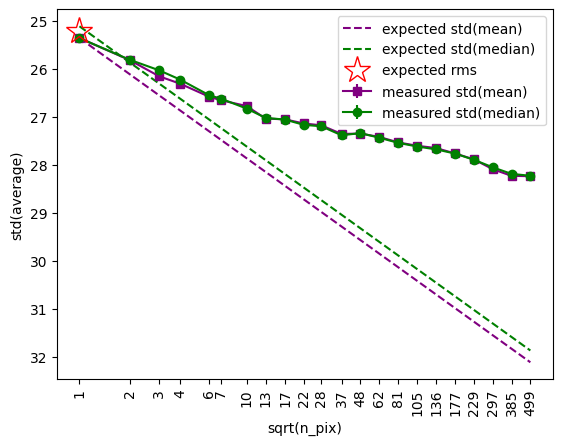

In [ ]:
results_original_bkgsub, _ = measure(filename, path / "stacked_original", mask=mask_original, bkg_mesh_size=500, outpath=path / "stacked_original" / "background_stats_bkgsub")

100%|██████████| 22/22 [01:30<00:00,  4.11s/it]


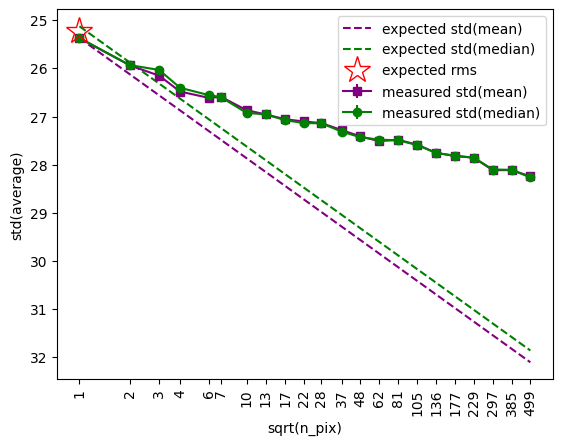

In [ ]:
results_original_remasked_bkgsub, _ = measure(filename, path / "stacked_original", mask=mask, bkg_mesh_size=500, outpath=path / "stacked_original" / "background_stats_remasked_bkgsub")

100%|██████████| 22/22 [01:32<00:00,  4.20s/it]


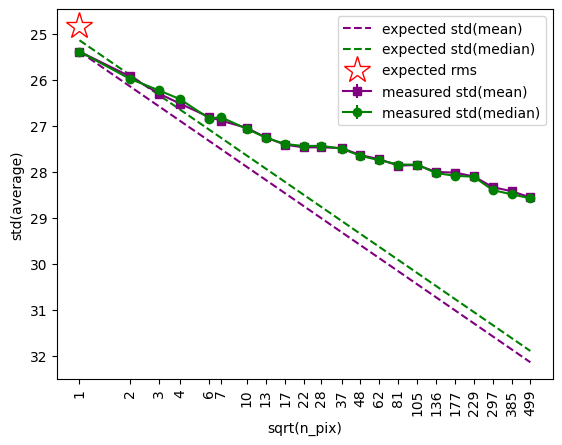

In [ ]:
results_processed_bkgsub, _ = measure(filename, path / "stacked", mask=mask, bkg_mesh_size=500, outpath=path / "stacked" / "background_stats_bgsub")

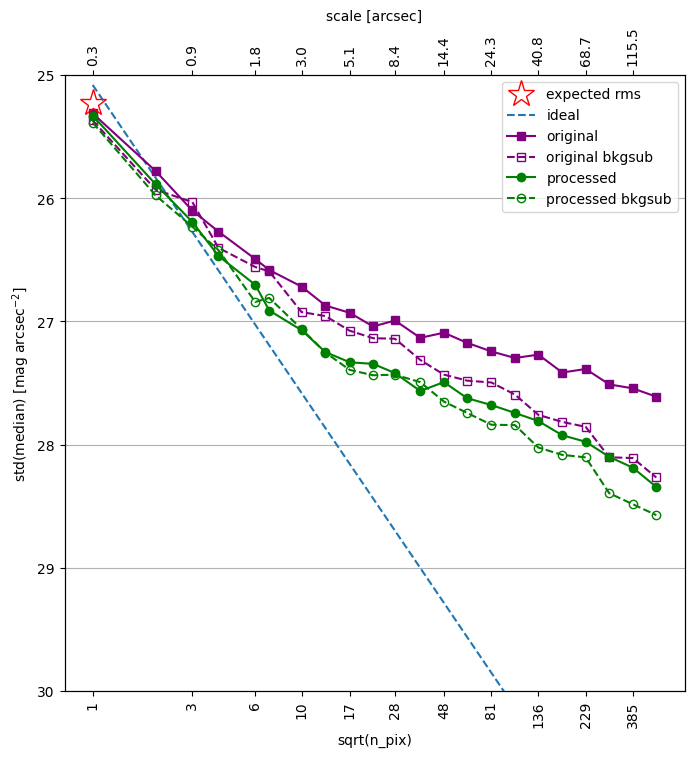

In [ ]:
zp_mag = 21.286
pix_scale = 0.3
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(1, results_original["expected_std_from_rms_mean"][0], "*", color="red", mfc="none", markersize=20, label="expected rms", zorder=10)
ax.plot(
    results_processed["sqrt_n_pix"],
    results_original["expected_std_median"],
    "--",
    label="ideal",
)
ax.plot(
    results_original_remasked["sqrt_n_pix"], results_original_remasked["std_median"], linestyle="-", marker="s", color="purple", label="original"
)
ax.plot(
    results_original_remasked_bkgsub["sqrt_n_pix"], results_original_remasked_bkgsub["std_median"], linestyle="--", marker="s", color="purple", mfc='none', label="original bkgsub"
)
ax.set_xscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
ax.xaxis.set_ticks(results_original["sqrt_n_pix"][::2], [f"{x:.0f}" for x in results_original["sqrt_n_pix"][::2]])
ax.xaxis.set_minor_locator(NullLocator())
ax.set_xlabel("sqrt(n_pix)")
ax.set_ylabel("std(median) [mag arcsec$^{-2}$]")
ax.tick_params(axis='x', labelrotation=90)
ax.legend()
ax.grid(axis='y')
ax.yaxis.set_inverted(True)
ax.set_ylim(30, 25)
ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_xlabel('scale [arcsec]')
ax2.xaxis.set_ticks(results_original["sqrt_n_pix"][::2], [f"{x:.1f}" for x in results_original["sqrt_n_pix"][::2] * pix_scale])
ax2.xaxis.set_minor_locator(NullLocator())
ax2.tick_params(axis='x', labelrotation=90)
ax2.set_xlim(ax.get_xlim())
outpath = path / "background_stats"
outpath.mkdir(parents=True, exist_ok=True)
outfile = (outpath / "original.pdf")
fig.savefig(outfile)
ax.plot(
    results_processed["sqrt_n_pix"], results_processed["std_median"], linestyle="-", marker="o", color="green", label="processed"
)
ax.plot(
    results_processed_bkgsub["sqrt_n_pix"], results_processed_bkgsub["std_median"], linestyle="--", marker="o", color="green", mfc="none", label="processed bkgsub"
)
ax.legend()
ax.yaxis.set_inverted(True)
outfile = (outpath / "original_vs_processed.pdf")
fig.savefig(outfile)

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()